<H1>Assignment: Linear Regression Techniques</H1>

<b>Objective:</b>

This assignment focuses on exploring the impact of regularization in Ridge Regression models when handling datasets with outliers. Using a synthetic dataset modeled on a sine function with added noise, including a specific outlier, students will evaluate how the regularization parameter, alpha, affects model performance.

<b>Dataset:</b>

The dataset simulates the function sin(2πx) with x values uniformly distributed between 0 and 1. Gaussian noise is added to introduce real-world data variability. An outlier at the point (0.5, 2) is explicitly included in the training data to examine the robustness of the regression models against outliers. The dataset includes 50 points for training and testing.


<H2>Exercises:</H2>

<b>Task 1.1: RidgeRegression</b>
<ol>
  <li>Implement a ridge regression model using scikit-learn's <code>KernelRidge()</code>.
  <li>Try different kernels (‘polynomial’, ‘rbf’) and appropriate hyperparameters of the kernel ('gamma', and 'degree')</li>
  <li>Evaluate the model's performance using the mean squared error (MSE) metric (see sklearn.metrics).</li>
  <li>Plot the regression model including the data.</li>
  <li>What is the impact of the weight value for the regularizer ('alpha')? 
</ol>

<b>Task 1.2: RidgeRegression Parameter Grid Search</b>
<ol>
  <li>Utilize scikit-learn's <code>GridSearchCV()</code> method to find an optimal set of hyperparameters.</li>
  <li>Use for example: "alpha": [1e0, 0.1, 1e-2, 1e-3], "gamma": np.logspace(-10, 10, 100), "degree": [2, 3, 4, 5]</li>
<li>Print the optimal parameter values and compare the performance to your best model from Task 1.1</li>
</ol>


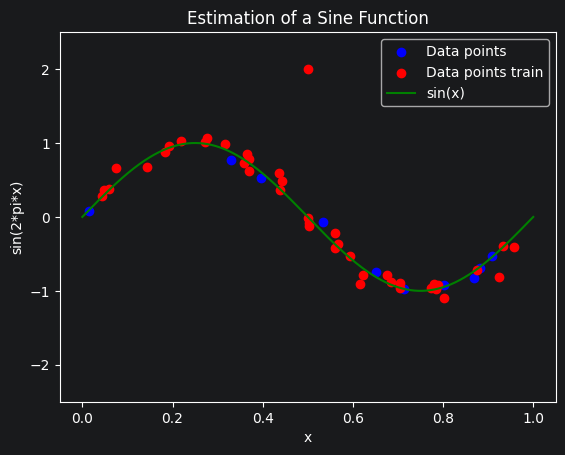

Polynomial (alpha=0.1, degree=3): MSE = 0.1612
RBF (alpha=0.1, gamma=5): MSE = 0.0139
RBF (alpha=0.001, gamma=5): MSE = 0.0108


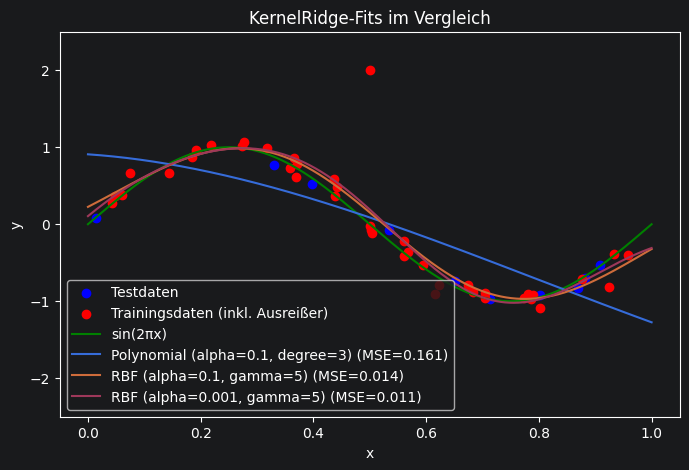

Beste RBF-Parameter: {'alpha': 0.01, 'gamma': np.float64(3.1992671377973845)}
Test-MSE (bester RBF): 0.012020265305692352
Beste Polynomial-Parameter: {'alpha': 0.001, 'degree': 4}
Test-MSE (bester Polynomial): 0.013794169846668782


In [1]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
import numpy as np


def func(x):
    return np.sin(2 * np.pi * x)

size = 50
rng = np.random.RandomState(1234)
X = rng.uniform(0.0, 1.0, size)
y = func(X) + rng.normal(scale=0.1, size=size)
X=X.reshape(-1, 1)
y=y.reshape(-1, 1)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = np.append(X_train,[[0.5]], axis=0)
y_train = np.append(y_train,[[2]], axis=0)


# Plot the data points
plt.scatter(X_test, y_test, color='blue', label='Data points')
plt.scatter(X_train, y_train, color='red', label='Data points train')

X_plot = np.linspace(0, 1, 100000)[:, None]
y_gt = func(X_plot) 
plt.plot(X_plot, y_gt, color='green', label='sin(x)')
plt.xlabel('x')
plt.ylabel('sin(2*pi*x)')
plt.title('Estimation of a Sine Function')
plt.ylim([-2.5,2.5])
plt.legend()
plt.show()

#Task1.1
from sklearn.metrics import mean_squared_error
from sklearn.kernel_ridge import KernelRidge

models = {
    "Polynomial (alpha=0.1, degree=3)": KernelRidge(kernel="polynomial", alpha=0.1, degree=3),
    "RBF (alpha=0.1, gamma=5)":         KernelRidge(kernel="rbf", alpha=0.1, gamma=5),
    "RBF (alpha=0.001, gamma=5)":       KernelRidge(kernel="rbf", alpha=0.001, gamma=5),
}

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Testdaten')
plt.scatter(X_train, y_train, color='red', label='Trainingsdaten (inkl. Ausreißer)')
plt.plot(X_plot, y_gt, color='green', label='sin(2πx)')

for name, model in models.items():
    model.fit(X_train, y_train.ravel())
    y_pred_test = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred_test)
    print(f"{name}: MSE = {mse:.4f}")

    y_pred_plot = model.predict(X_plot)
    plt.plot(X_plot, y_pred_plot, label=f"{name} (MSE={mse:.3f})")

plt.xlabel('x')
plt.ylabel('y')
plt.title('KernelRidge-Fits im Vergleich')
plt.ylim([-2.5, 2.5])
plt.legend()
plt.show()

#Task1.2
from sklearn.model_selection import GridSearchCV

param_grid_rbf = {
    "alpha": [1e0, 0.1, 1e-2, 1e-3],
    "gamma": np.logspace(-10, 10, 100),
}
gs_rbf = GridSearchCV(KernelRidge(kernel="rbf"), param_grid_rbf, cv=5, scoring="neg_mean_squared_error")
gs_rbf.fit(X_train, y_train.ravel())

print("Beste RBF-Parameter:", gs_rbf.best_params_)
y_pred_best_rbf = gs_rbf.predict(X_test)
print("Test-MSE (bester RBF):", mean_squared_error(y_test, y_pred_best_rbf))

param_grid_poly = {
    "alpha": [1e0, 0.1, 1e-2, 1e-3],
    "degree": [2, 3, 4, 5],
}
gs_poly = GridSearchCV(KernelRidge(kernel="polynomial"), param_grid_poly, cv=5, scoring="neg_mean_squared_error")
gs_poly.fit(X_train, y_train.ravel())

print("Beste Polynomial-Parameter:", gs_poly.best_params_)
y_pred_best_poly = gs_poly.predict(X_test)
print("Test-MSE (bester Polynomial):", mean_squared_error(y_test, y_pred_best_poly))